In [1]:
# capstone project -- function 3 (3D), week N

import numpy as np
import warnings
import matplotlib.pyplot as plt

from scipy.spatial import Delaunay  # convex-hull membership check for the proposal

from bayes_tools import (
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ei_acquisition, max_variance_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    compare_xi_proposals, print_xi_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_nd_slices, plot_loo_calibration, plot_xi_sensitivity,
    plot_acquisition_backtest,
    plot_convergence, plot_acquisition_decay, plot_uncertainty_shrinkage,
    plot_step_distance,
)

# Function 3

3D. This week deliberately departs from the standard recipe: **bounds are the observed data's bounding box, the acquisition is `max_variance`, and the proposal is restricted to the one input dimension the GP finds informative.** The reasoning is below -- it's a response to the standard recipe proposing an extrapolated corner, and it's a one-week decision, not a new project default.

Proposal this week: **`[0.492581, 0.611593, 0.669818]`** (GP mean -0.106, std 0.089).

## What changed from the previous version of this notebook

The old version called `init_history`/`load_history`/`propose_and_log`/`record_observation`. **Those functions no longer exist** -- the file-based history log was removed from `bayes_tools.py` in favour of plain in-memory arrays, so the old notebook can't run at all. State now lives in `new_X`/`new_y` and per-iteration diagnostics are reconstructed by replaying ordered `X`/`y` through `compute_iteration_diagnostics`.

Also fixed: the old version built bounds with `initial_bounds(X, pad_fraction=1.0)` and no lower limit, producing a lower bound of about **-0.87, -0.50, -0.86** -- physically impossible negative inputs.

Dropped the old `length_scale_bounds=(1e-2, 100.0)` override too. Raising the ceiling doesn't buy information: a length-scale pinned at the bound just means "this axis looks irrelevant", and it says that at 10 as clearly as at 100.

## Why this week deviates: the standard recipe proposes an extrapolated corner

With the project-standard `pad_fraction=1.0, lower_limit=0.0` bounds and EI, the proposal is `[1.885181, 1.662802, 0.0]` -- **all three coordinates on a bound, all three outside the observed data range**. The diagnosis:

- The GP fits ARD length-scales of about **[10.0, 10.0, 0.056]** under those bounds: x0 and x1 are *pinned at the upper bound*, so the GP sees only **x2** as informative. Plain correlations agree -- x2 has `r = -0.565` (`p = 0.023`, the only significant one), against x0 `r = +0.227` (`p = 0.40`) and x1 `r = +0.109` (`p = 0.69`).
- With the acquisition surface flat along x0 and x1, its argmax on those axes is arbitrary -- decided by wherever the L-BFGS-B optimiser stops, which is a boundary.
- `pad_fraction=1.0` doubles each dimension's range, so the data occupies only ~49% / 43% / 48% of each axis -- **about 10% of the box by volume**. The rest is extrapolation with no data in it.

**Tuning `xi` does not fix this.** Swept across 0 to 0.35, every value leaves 2 or 3 coordinates outside the observed data range (`xi >= 0.02` gets off the literal corner but still puts x0 at 1.16 and x2 at 1.91, against observed maxima of 0.966 and 0.991), and the response is non-monotone. `xi` is the wrong dial; the bounds and the acquisition are the right ones.

## Terminology: bounding box vs. convex hull

These are two different things and the distinction matters here.

- The **bounding box** is the per-dimension min/max of the observed data -- an axis-aligned rectangle. This is what `bounds_box` holds, and it's the only kind of constraint the tooling can enforce: `initial_bounds`, `fit_gp`, and `generate_next_point` all take a `(D, 2)` box.
- The **convex hull** is the smallest convex set containing the observations -- the shape you'd get shrink-wrapping them. It's always inside the bounding box, here occupying only **34.5%** of it (0.212 vs 0.613 by volume). With 16 points in 3D, 11 of them are hull vertices, so the cloud is nearly all surface and the box is a poor proxy for it.

Consequence: constraining the search to the bounding box does **not** make extrapolation impossible. It only guarantees that no coordinate exceeds the range already seen *on its own axis*. A corner of the box can pass that test while sitting well outside the data cloud -- and that isn't hypothetical here. Both the unconstrained `max_variance` proposal and EI's in-box proposal are inside the box and **outside** the convex hull, because both park x0/x1 at opposing box edges. Only the restricted construction below is inside both. The proposal cell checks hull membership explicitly, which is the stronger and more meaningful test.

## Why not EI even inside the box

Confined to the bounding box, EI picks x2 ~ 0.858 for every `xi` from 0 to 0.05. It does that because the posterior mean *bumps up* to about -0.044 there, sitting between observations at x2=0.771 (`y = -0.118`) and x2=0.920 (`y = -0.114`). A short length-scale (0.104 under box bounds) with a fitted amplitude above the data variance overshoots between sparse points -- EI is chasing ringing, not signal. Both brackets also agree closely, so the answer there is largely predictable and buys little. And as noted above, its proposal falls outside the convex hull.

## What this week does instead

1. **Bounds = the observed bounding box**, so no coordinate can exceed the range already seen on its own axis.
2. **`max_variance`** as the acquisition -- pure uncertainty reduction. Independently, `ucb` with `kappa=5` picks essentially the same place, which is reassuring.
3. **Search restricted to x2**, holding x0/x1 at the incumbent `[0.4926, 0.6116]`. Since x0/x1 are non-informative, letting a flat acquisition choose them parks them at an arbitrary box edge *outside the data cloud*; pinning them at the incumbent keeps the point inside the convex hull, which is what makes it genuine interpolation.

The proposal lands at **x2 = 0.6698**, in the largest gap on the only axis that matters (0.567 to 0.771, width 0.204), where posterior std peaks at 0.0887. The constrained and unconstrained searches agree on that x2 to within 0.0001, so the restriction costs nothing in acquisition value -- it only fixes where x0/x1 sit.

Crucially the brackets **disagree** (`y = -0.057` below, `y = -0.118` above), so the evaluation is informative either way: it either confirms the monotone decline in x2 -- letting later weeks concentrate on low x2, where both best points sit (x2=0.340 and 0.066, both about -0.035) -- or exposes real structure the GP is currently inventing.

**Caveats.** This is a deliberate deviation from the CLAUDE.md standard (`pad_fraction=1.0`); it is not a new default, and the standard bounds are still computed below for comparison. Box bounds also mean the search can never expand past the initial batch's footprint, so this shouldn't persist for many weeks. And "only x2 matters" rests on 16 points in 3D, so it may be under-fitting rather than truth -- if you'd rather test *that*, the alternative experiment is a very different x0/x1 at a well-sampled x2, which is a different week's question.

## What the acquisition backtest says (and doesn't)

Under this week's box bounds it ranks `exploit` 0.0350, `ucb_k1` 0.0460, `pi_xi001` 0.0485, `ei_xi001` 0.0485, `ucb_k5` 0.0689, `max_var` 0.1387 -- so by that metric this week's choice comes **last**. That is expected and not an objection. Regret is scored by picking among held-out points whose true `y` the scorer already knows, so the metric rewards whatever ranks closest to the GP posterior mean: recognition is inherently an *exploitation* task with no credit for reducing uncertainty, which is precisely what `max_variance` is for. The top four also sit within 0.014 with near-identical median regret, so the ordering is weak anyway. Treat the backtest as an exploitation-phase tool for later, not a verdict on an exploration week.

## Dimensionality-specific choices

- `plot_2d_bo` doesn't apply at D=3, so the GP/acquisition view is **`plot_nd_slices`** -- one 1D slice per dimension through the current best point.
- `plot_bo_diagnostics` and `plot_sample_trajectory` hard-code a 2D scatter panel, so they're **skipped**; the individual trend plots are dimension-agnostic and used instead.
- **No y-scaling.** Function 3's `y` runs about -0.399 to -0.035, so `xi=0.01` is ~2.7% of the spread -- inside the 0.1%-10% band where scaling isn't needed. Any `xi` below is in raw `y`-units.

In [2]:
X_initial = np.load("initial_data/function_3/initial_inputs.npy")
y_initial = np.load("initial_data/function_3/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

assert D == 3, f"Expected a 3D problem, got {D}D input -- check the loaded file."

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))

## Update this once per week

Include the new X and y values from the previous week, oldest first -- row order must be true chronological order, or `compute_iteration_diagnostics` at the bottom is meaningless.

One observation is recorded so far. It predates the switch away from PI (the old version of this notebook proposed with `pi`/`xi=0.01`), so the history is mixed in terms of what chose each point. The diagnostics section explains how the replay handles that.

In [3]:
# Append last week's result BEFORE proposing this week's point, e.g.:
#
# new_X, new_y = append_observations(new_X, new_y, x_next, the_result_you_got)

new_X = np.array([
    [0.270875, 0.2582, 0.418474],
])

new_y = np.array([-0.05641777085561445])

print("observations collected so far:", len(new_y))

observations collected so far: 1


## Build the full dataset (initial + everything collected so far)

In [4]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

# The project-standard bounds. X is known to never be negative, so
# lower_limit=0.0 is mandatory -- without it this function's padded bounds
# start at about -0.87 / -0.50 / -0.86, which are impossible inputs.
bounds_standard = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)
validate_bounds_consistency(X, bounds_standard)

# DELIBERATE DEVIATION THIS WEEK (see header): search only the axis-aligned
# bounding box of the observed data, so no coordinate can exceed the range
# already seen on its own axis. NOTE this is the bounding BOX, not the convex
# hull -- a corner of the box can still be far outside the data cloud, so this
# constrains extrapolation without eliminating it. The proposal cell checks
# convex-hull membership separately. Revert to bounds_standard once the GP has
# reason to prefer a direction along x0/x1, or the search can never expand
# beyond the initial batch's footprint.
bounds_box = np.column_stack([X.min(axis=0), X.max(axis=0)])
validate_bounds_consistency(X, bounds_box)

bounds = bounds_box

print("\nstandard bounds (pad_fraction=1.0):\n", np.round(bounds_standard, 4))
print("\nobserved bounding box (USED THIS WEEK):\n", np.round(bounds_box, 4))

print("\nfraction of each standard-bounds axis actually covered by data:")
frac = 1.0
for d in range(D):
    f = (X[:, d].max() - X[:, d].min()) / (bounds_standard[d, 1] - bounds_standard[d, 0])
    frac *= f
    print(f"  x{d}: {f:.1%}")
print(f"  -> {frac:.1%} of the standard box by volume; the rest is extrapolation")

# How loose is the bounding box as a stand-in for "where the data is"? In 3D
# with few points the cloud is nearly all surface, so the box overstates it.
hull = Delaunay(X)
box_volume = float(np.prod(bounds_box[:, 1] - bounds_box[:, 0]))
try:
    from scipy.spatial import ConvexHull
    ch_volume = ConvexHull(X).volume
    print(f"\nbounding box volume: {box_volume:.5f} | true convex hull volume: {ch_volume:.5f}"
          f" ({ch_volume / box_volume:.1%} of the box)")
except Exception as exc:  # degenerate point set -- not fatal, just skip
    print("\nconvex hull volume unavailable:", exc)

xi_frac = 0.01 / (y.max() - y.min())
print(f"\nxi=0.01 is {xi_frac:.2%} of the y spread "
      f"-> {'scaling NOT needed' if 0.001 <= xi_frac <= 0.1 else 'CONSIDER y-scaling'}")

X_initial shape: (15, 3) | y_initial shape: (15,)
new_X shape:      (1, 3) | new_y shape:      (1,)
combined X shape: (16, 3) | combined y shape: (16,)

X range per dimension:
  min: [0.04680895 0.21991724 0.06608864]
  max: [0.96599485 0.94135983 0.99088187]
y range: -0.3989255131463011 to -0.034835313350078584

standard bounds (pad_fraction=1.0):
 [[0.     1.8852]
 [0.     1.6628]
 [0.     1.9157]]

observed bounding box (USED THIS WEEK):
 [[0.0468 0.966 ]
 [0.2199 0.9414]
 [0.0661 0.9909]]

fraction of each standard-bounds axis actually covered by data:
  x0: 48.8%
  x1: 43.4%
  x2: 48.3%
  -> 10.2% of the standard box by volume; the rest is extrapolation

bounding box volume: 0.61327 | true convex hull volume: 0.21164 (34.5% of the box)

xi=0.01 is 2.75% of the y spread -> scaling NOT needed


## Backtest acquisition functions (using only data already collected)

A weak, free check on acquisition family: repeatedly split the data into a "seed" set (fits the GP) and a held-out "candidate" set (true y known, hidden from the fit), then see which config would have picked the best candidate most often. No new evaluations spent.

**Expect `max_variance` to come last, and expect that not to matter.** The metric scores recognition of points whose true `y` is already known, which is an exploitation task -- it rewards whatever ranks closest to the GP posterior mean and gives no credit for reducing uncertainty. A pure uncertainty-seeker is therefore penalised by construction, so this table cannot be used to argue against this week's choice. See the header.

The ordering among the *other* configs is weak too: the top four sit within about 0.014 with near-identical median regret (PI and EI are separated by 0.00005), and on function 2 the leader changed when a single observation was added.

Note these numbers move with the bounds, since the bounds set the input normalisation the GP is fit on -- they'll differ from a week run on the standard padded bounds. Don't compare across bounds choices.

LIMITATION: this only tests recognition of good points *already in the dataset*. It cannot test which config is best at proposing a genuinely new location, since there's no ground truth for that without a real evaluation -- which is exactly the question that matters this week. Kept because it's cheap and becomes informative later, once there are more points and the goal shifts to drilling in.

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/pytho

      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     exploit |      0.03497 |        0.02158 |        -0.0745
      ucb_k1 |      0.04601 |        0.02175 |       -0.08554
    pi_xi001 |      0.04848 |        0.02192 |       -0.08801
    ei_xi001 |      0.04853 |        0.02192 |       -0.08806
      ucb_k5 |      0.06887 |        0.04941 |        -0.1084
     max_var |       0.1387 |        0.07501 |        -0.1782


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


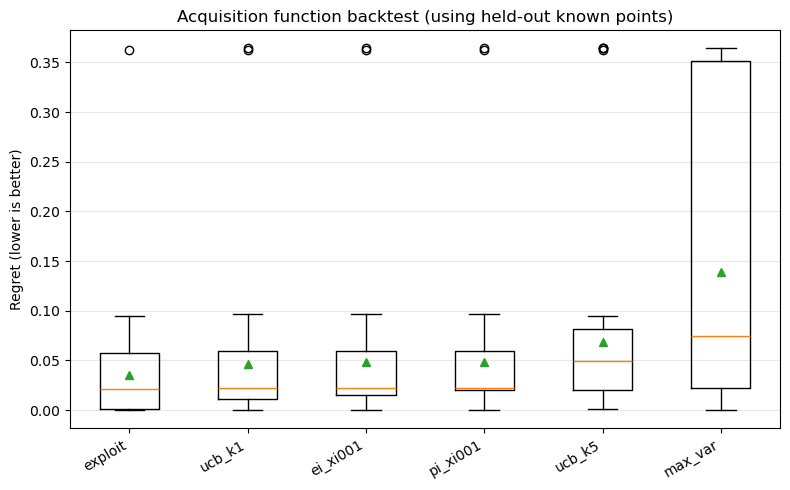

In [5]:
# xi/kappa are in raw y-units here (no y-scaling in this notebook -- see header).
backtest_configs = [
    {"name": "ei_xi001", "acquisition": "ei",  "xi": 0.01},
    {"name": "pi_xi001", "acquisition": "pi",  "xi": 0.01},
    {"name": "ucb_k1",   "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k5",   "acquisition": "ucb", "kappa": 5.0},
    {"name": "exploit",  "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

backtest_results = backtest_acquisitions(
    X, y, bounds, backtest_configs,
    n_repeats=50, seed_frac=0.5, maximize=True,
    gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
)
print_backtest_summary(backtest_results)

fig = plot_acquisition_backtest(backtest_results)
plt.show()

## Sensitivity check: which dimensions actually matter

Per-dimension ARD length-scales. Short = the function varies quickly along that axis, so it matters. Pinned at the upper `length_scale_bounds` = the GP sees that axis as close to irrelevant.

**Only "pinned vs. not pinned" is trustworthy** -- don't compare two dimensions that are both pinned. Expect x0 and x1 pinned at 10.0 and only x2 short (~0.104 under this week's box bounds; ~0.056 under the wider standard bounds, since the rescale compresses the data).

This cell is load-bearing for the whole approach: the proposal below restricts its search to whichever dimensions come back non-pinned, and warns if that stops being exactly one. It also explains why the `plot_nd_slices` panels for x0 and x1 look flat -- that's the model, not a plotting bug.

In [6]:
gp_check = fit_gp(X, y, bounds, n_restarts_optimizer=20, random_state=0)
length_scales = get_length_scales(gp_check)

PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
for dim, ls in sorted(enumerate(length_scales), key=lambda t: t[1]):
    pinned = ls >= 0.999 * PINNED
    tag = "<- PINNED, looks irrelevant" if pinned else (
        "(most sensitive)" if ls == length_scales.min() else "")
    print(f"x{dim}: length_scale = {ls:8.3f} {tag}")

informative = [d for d, ls in enumerate(length_scales) if ls < 0.999 * PINNED]
print("\ndimensions the GP currently treats as informative:", informative)

x2: length_scale =    0.104 (most sensitive)
x0: length_scale =   10.000 <- PINNED, looks irrelevant
x1: length_scale =   10.000 <- PINNED, looks irrelevant

dimensions the GP currently treats as informative: [2]


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Why not EI: the xi sweep, kept as evidence

**This section no longer chooses the proposal** -- it's the record of why EI was set aside this week. `xi` is EI's improvement margin in raw `y`-units (observed spread ~0.36).

Three things to read off the table:

1. **`xi` doesn't move the proposal off the pathology.** Under the standard bounds every value from 0 to 0.35 lands 2-3 coordinates outside the observed range; under box bounds every value from 0 to 0.05 lands on essentially the same x2 (~0.855-0.859). Either way `xi` is not the dial that matters here.
2. **EI's target is model ringing.** x2 ~ 0.858 wins because the posterior mean bumps to about -0.044 there, between observations at x2=0.771 (`y = -0.118`) and x2=0.920 (`y = -0.114`). A short length-scale with a large fitted amplitude overshoots between sparse points.
3. **Its x0/x1 land on a box corner.** Every row proposes x0 ~ 0.966, x1 ~ 0.941 -- both at their maxima, which is outside the convex hull of the data even though inside the box.

Re-run this each week. If a future refit stops pinning x0/x1, or the x2 profile stops ringing, EI becomes the sensible default again and this notebook should go back to it.

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


      xi |                   x_next |  acq_value |  pred_mean |  pred_std |  dist_from_best
-------------------------------------------------------------------------------------------
       0 |      [0.966,0.941,0.859] |     0.0204 |    -0.0441 |    0.0621 |          0.7760
   0.002 |      [0.966,0.941,0.859] |     0.0196 |    -0.0441 |    0.0622 |          0.7759
    0.01 |      [0.966,0.941,0.858] |     0.0164 |    -0.0444 |    0.0624 |          0.7755
   0.025 |      [0.966,0.941,0.857] |     0.0114 |    -0.0449 |    0.0629 |          0.7747
    0.05 |      [0.966,0.941,0.855] |     0.0057 |    -0.0457 |    0.0635 |          0.7735


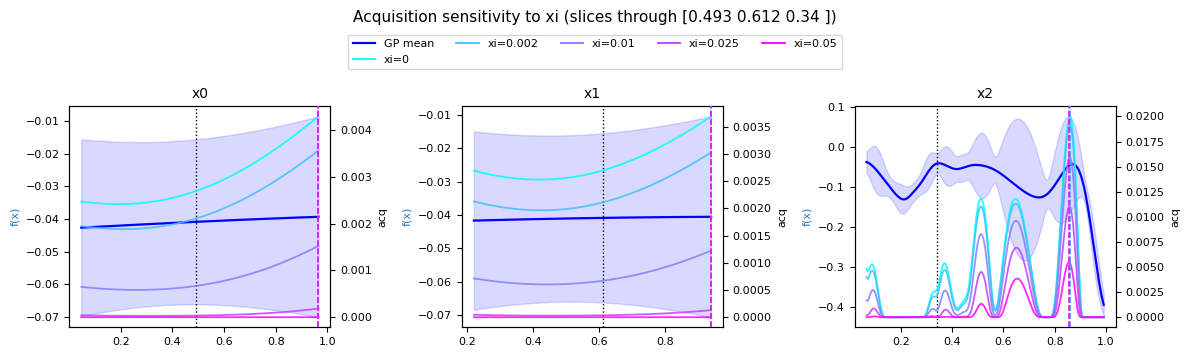


incumbent (best observed point): [0.4926 0.6116 0.3402]  y = -0.0348

GP profile along x2 (x0/x1 held at the incumbent):
     x2 |   GP mean |  GP std |  nearest observed y
   0.10 |   -0.0536 |  0.0288 |   -0.0364 (x2=0.066)
   0.34 |   -0.0409 |  0.0130 |   -0.0348 (x2=0.340)
   0.57 |   -0.0582 |  0.0179 |   -0.0568 (x2=0.567)
   0.65 |   -0.0963 |  0.0854 |   -0.0568 (x2=0.567)
   0.67 |   -0.1060 |  0.0887 |   -0.1180 (x2=0.771)
   0.77 |   -0.1174 |  0.0181 |   -0.1180 (x2=0.771)
   0.86 |   -0.0440 |  0.0610 |   -0.1139 (x2=0.920)
   0.92 |   -0.1179 |  0.0153 |   -0.1139 (x2=0.920)
   0.99 |   -0.3917 |  0.0158 |   -0.3989 (x2=0.991)


In [7]:
xi_rows = compare_xi_proposals(X, y, bounds, xi_values=[0.0, 0.002, 0.01, 0.025, 0.05],
                                acquisition="ei", maximize=True, n_restarts=20, random_state=0)
print_xi_comparison(xi_rows)

fig = plot_xi_sensitivity(X, y, bounds, gp_check, xi_rows, ei_acquisition, maximize=True)
plt.show()

# The posterior-mean bump EI is chasing, shown numerically along x2 with
# x0/x1 held at the incumbent. Note the rise between the two bracketing
# observations rather than a trend toward either of them.
incumbent = X[np.argmax(y)]
print(f"\nincumbent (best observed point): {np.round(incumbent, 4)}  y = {y.max():.4f}")
print("\nGP profile along x2 (x0/x1 held at the incumbent):")
print(f"{'x2':>7} | {'GP mean':>9} | {'GP std':>7} | {'nearest observed y':>19}")
for v in [0.10, 0.34, 0.57, 0.65, 0.67, 0.77, 0.86, 0.92, 0.99]:
    p = incumbent.copy()
    p[2] = v
    m, s = gp_check.predict(normalize(p.reshape(1, -1), bounds), return_std=True)
    j = int(np.argmin(np.abs(X[:, 2] - v)))
    print(f"{v:7.2f} | {m[0]:+9.4f} | {s[0]:7.4f} | {y[j]:+9.4f} (x2={X[j, 2]:.3f})")

## Propose the next point: max-variance along the informative dimension

Three steps, in order:

1. Confirm which dimensions the GP treats as informative (recomputed here rather than assumed -- if this changes, the whole approach below should be revisited).
2. Find the unconstrained `max_variance` proposal within the box, for reference. Its x2 is the number that matters; its x0/x1 are arbitrary because the acquisition is flat along them.
3. Build the point actually submitted: x2 from a fine scan along the informative axis, x0/x1 pinned at the incumbent so the point sits inside the data cloud rather than on an arbitrary box edge.

Two checks then run on the result. The **per-axis** check (within the observed range on every dimension independently) is guaranteed by the box bounds and should never fire. The **convex-hull** check is strictly stronger and is the one that matters: a point can be in range on every axis and still sit outside the data cloud entirely. That's exactly what happens to both the unconstrained `max_variance` proposal and EI's in-box proposal -- both pass the per-axis check and fail the hull check, because they park x0/x1 at opposing box edges. The restricted construction in step 3 passes both.

In [8]:
# --- 1. Which dimensions does the GP actually use? -------------------------
PINNED = 10.0  # fit_gp's default length_scale_bounds upper limit
informative = [d for d, ls in enumerate(get_length_scales(gp_check)) if ls < 0.999 * PINNED]
flat = [d for d in range(D) if d not in informative]
print("informative dimensions:", informative, "| flat (pinned) dimensions:", flat)

if len(informative) != 1:
    print("\n*** The 'one informative axis' assumption no longer holds. ***")
    print("Re-read the header: the restricted-search construction below was")
    print("justified by exactly one non-pinned dimension. Reconsider before using.")

# --- 2. Unconstrained max_variance within the box, for reference -----------
x_unconstrained, gp = generate_next_point(
    X, y, bounds,
    acquisition="max_variance",
    maximize=True,
    n_restarts=40,
    random_state=0,
)
mu_u, sd_u = gp.predict(normalize(x_unconstrained.reshape(1, -1), bounds), return_std=True)
print(f"\nunconstrained max_variance: {np.round(x_unconstrained, 4)}"
      f"  mean={mu_u[0]:+.4f} std={sd_u[0]:.4f}")
print(f"  in convex hull of the data: {hull.find_simplex(x_unconstrained) >= 0}")
print("  (its x0/x1 are arbitrary -- the acquisition is flat along them)")

# --- 3. The point actually proposed ---------------------------------------
# Scan the informative axis at fine resolution, holding the flat axes at the
# incumbent. Uses the same acquisition as step 2, so the two are comparable.
DIM = informative[0] if len(informative) == 1 else int(np.argmin(get_length_scales(gp_check)))
scan = np.tile(incumbent, (2000, 1))
scan[:, DIM] = np.linspace(bounds[DIM, 0], bounds[DIM, 1], 2000)
scan_norm = normalize(scan, bounds)
acq_vals = max_variance_acquisition(scan_norm, gp)

x_next = scan[int(np.argmax(acq_vals))]
mu, sigma = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 6))
print(gp.kernel_)
print(f"GP predicted mean: {mu[0]:.4g}, predicted std: {sigma[0]:.4g}")

drift = abs(x_next[DIM] - x_unconstrained[DIM])
print(f"\nx{DIM} agreement between constrained and unconstrained: "
      f"{x_next[DIM]:.4f} vs {x_unconstrained[DIM]:.4f} (drift {drift:.4f})")
if drift > 0.05:
    print("*** They disagree. The flat-axis assumption may have broken down -- check before submitting. ***")

# --- Safety checks --------------------------------------------------------
# Weak check: within the observed range on every axis independently. Box
# bounds guarantee this, so it should never fire.
on_edge = [d for d in range(D)
           if np.isclose(x_next[d], bounds[d, 0]) or np.isclose(x_next[d], bounds[d, 1])]
outside = [d for d in range(D) if not (X[:, d].min() <= x_next[d] <= X[:, d].max())]
print("\ndimensions where x_next sits on a bound:", on_edge or "none")
print("dimensions where x_next is outside the observed data range:", outside or "none")

# Strong check: inside the actual convex hull of the observations. This is
# strictly harder than the per-axis check above -- a box corner can pass that
# and fail this -- and it's the real test of "interpolation, not extrapolation".
in_hull = bool(hull.find_simplex(x_next) >= 0)
print(f"\nx_next inside the CONVEX HULL of the observations: {in_hull}")
if not in_hull:
    print("*** x_next is within range on every axis but outside the data cloud. ***")
    print("    That is still extrapolation. Consider moving the flat coordinates")
    print("    further toward the centre of the data before submitting.")

# Which observations bracket the proposal along the informative axis? The
# point is informative precisely because these two disagree.
below = X[X[:, DIM] <= x_next[DIM]]
above = X[X[:, DIM] >= x_next[DIM]]
y_below = y[X[:, DIM] <= x_next[DIM]]
y_above = y[X[:, DIM] >= x_next[DIM]]
if len(below) and len(above):
    lo_i, hi_i = int(np.argmax(below[:, DIM])), int(np.argmin(above[:, DIM]))
    print(f"\nbracketing observations along x{DIM}:")
    print(f"  below: x{DIM}={below[lo_i, DIM]:.3f}  y={y_below[lo_i]:+.4f}")
    print(f"  above: x{DIM}={above[hi_i, DIM]:.3f}  y={y_above[hi_i]:+.4f}")
    print(f"  gap width: {above[hi_i, DIM] - below[lo_i, DIM]:.3f}")

informative dimensions: [2] | flat (pinned) dimensions: [0, 1]

unconstrained max_variance: [0.0468 0.9414 0.6697]  mean=-0.1059 std=0.0889
  in convex hull of the data: False
  (its x0/x1 are arbitrary -- the acquisition is flat along them)

--- Next point to evaluate (bounds shape (3, 2)) ---
x_next: [0.492581 0.611593 0.669818]
1.43**2 * Matern(length_scale=[10, 10, 0.104], nu=2.5) + WhiteKernel(noise_level=0.0153)
GP predicted mean: -0.1059, predicted std: 0.08871

x2 agreement between constrained and unconstrained: 0.6698 vs 0.6697 (drift 0.0001)

dimensions where x_next sits on a bound: none
dimensions where x_next is outside the observed data range: none

x_next inside the CONVEX HULL of the observations: True

bracketing observations along x2:
  below: x2=0.567  y=-0.0568
  above: x2=0.771  y=-0.1180
  gap width: 0.204


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Visualise the GP and acquisition function via 1D slices

Each panel holds the other two dimensions fixed at the current best observed point and sweeps one dimension. Dotted line is the fixed centre, dashed red is the proposed `x_next`. The green acquisition curve is `max_variance`, i.e. the posterior std itself.

This is a *partial* view: it shows what the GP believes along each axis near the best point, not interactions between dimensions. Two things to expect:

- The **x0 and x1 panels are flat** -- both the GP mean and the acquisition. That's the pinned length-scales, not a plotting bug, and it's the whole reason the proposal fixes those coordinates at the incumbent instead of optimising them.
- The **x2 panel** should show the acquisition peaking in the 0.567-0.771 gap, where `x_next` sits, with visible ringing in the mean between sparse observations.

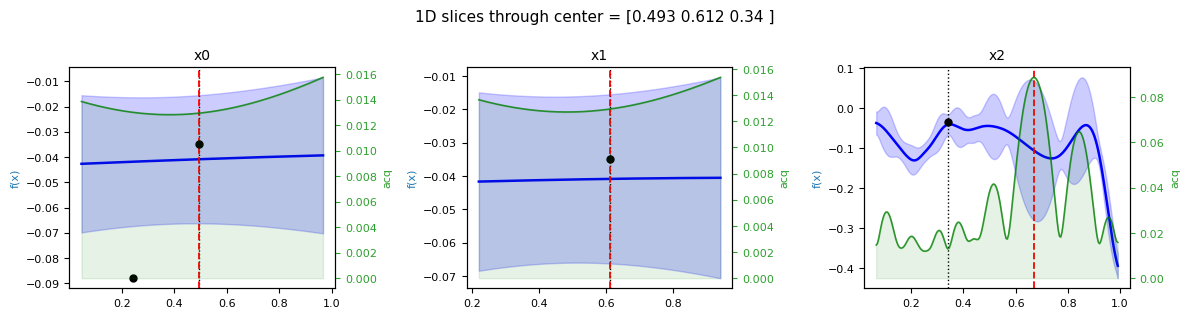

In [9]:
# max_variance_acquisition takes no extra kwargs -- it's just the posterior std.
fig = plot_nd_slices(
    X, y, bounds, gp,
    acquisition_fn=max_variance_acquisition,
    x_next=x_next,
    acq_kwargs={},
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Refits the GP once per observation, leaving it out, and predicts it from the rest. This matters more here than in 1D/2D, since you can no longer just look at the fitted surface and eyeball whether it's reasonable.

At 16 points the thing to read is whether the error bars cover the diagonal, not how tight the correlation is. Pay particular attention to the one strong outlier in this batch (`y = -0.399`, against a median around -0.10) -- if the GP can't predict it when held out, that's expected rather than alarming, but it does mean the surrogate is weak in whatever region that point occupies.

/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/pytho

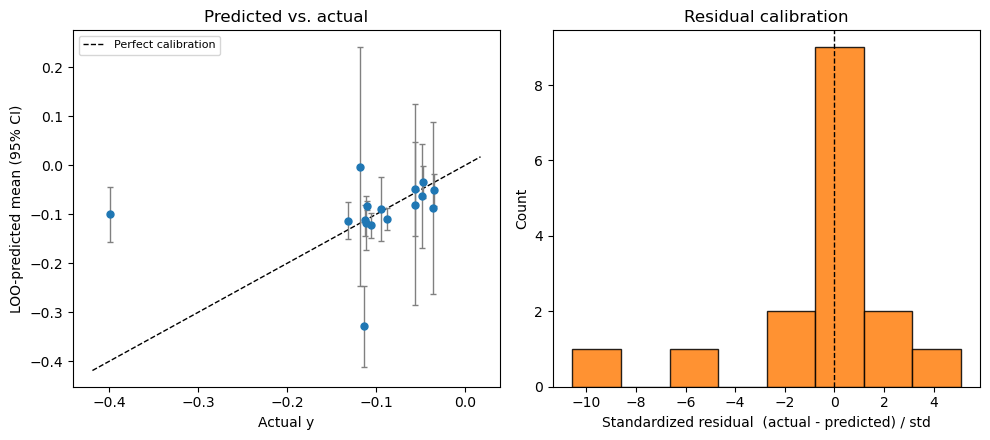

points inside their own 95% LOO interval: 13/16


In [10]:
pred_mean, pred_std = loo_predictions(X, y, bounds, gp_kwargs={"n_restarts_optimizer": 20})
fig = plot_loo_calibration(y, pred_mean, pred_std)
plt.show()

within = np.abs(y - pred_mean) <= 1.96 * pred_std
print(f"points inside their own 95% LOO interval: {within.sum()}/{len(y)}")

## Iteration diagnostics

`compute_iteration_diagnostics` replays the ordered `X`/`y` to reconstruct what the acquisition value, GP hyperparameters, and domain-wide uncertainty were at each past proposal -- no persisted log involved.

It applies **one** acquisition setting to the whole history, which is normally a hazard when the history is mixed (the single recorded observation here was proposed under the old notebook's `pi`/`xi=0.01`). Replaying with `max_variance` sidesteps that: its acquisition value is just the posterior std at the point *before* it was evaluated, which is a meaningful quantity however that point was chosen. So the `acq_value` column below reads as "how uncertain was the model there beforehand" and is interpretable across the mix.

Two caveats that still apply: it assumes row order is true chronological order, and it uses the bounds passed in -- which are this week's observed bounding box, so `domain_mean_std` is the mean uncertainty over that box, not over the standard padded box. Don't compare those numbers against a week that used different bounds.

`plot_bo_diagnostics` is skipped: it hard-codes a 2D scatter panel and this is a 3D problem. The individual trend plots below are dimension-agnostic, and need a few completed iterations before any trend is readable, so they're gated.

In [11]:
history = None
if len(new_y) == 0:
    print("No observations beyond the initial batch yet -- nothing to replay.")
    print("Best y so far:", y.max())
else:
    history = compute_iteration_diagnostics(X, y, bounds, n_initial=n_initial,
                                             acquisition="max_variance", maximize=True)
    print("Best y so far:", np.nanmax(history["y"]))
    print("completed iterations beyond the initial batch:", len(new_y))

    if len(new_y) >= 3:
        for plot_fn in (plot_convergence, plot_acquisition_decay,
                        plot_uncertainty_shrinkage, plot_step_distance):
            plot_fn(history)
            plt.show()
    else:
        print(f"\nOnly {len(new_y)} completed iteration(s) -- need at least 3 for the trend\n"
              "plots to say anything. Skipping them; the raw fields are below.")

Best y so far: -0.034835313350078584
completed iterations beyond the initial batch: 1

Only 1 completed iteration(s) -- need at least 3 for the trend
plots to say anything. Skipping them; the raw fields are below.


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Raw diagnostic fields

In [12]:
if history is not None:
    print("y:", history["y"])
    print("\niteration:", history["iteration"])
    print("\nacq_value (NaN = initial batch; see the caveat above):", history["acq_value"])
    print("\ndomain_mean_std:", history["domain_mean_std"])

y: [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.05641777]

iteration: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]

acq_value (NaN = initial batch; see the caveat above): [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.04895409]

domain_mean_std: [       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
        nan        nan        nan 0.03936493]


In [13]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))

0.492581-0.611593-0.669818

full precision (use for next week's new_X):
0.49258141463713434-0.6115931882759961-0.6698180855713872
